# 🔍 Stage 1 — Baseline Anomaly Detector on MVTec

# Zone 1 — Setup
*Run once per session. Defines everything but computes nothing.*

## 1. Imports & device

In [14]:
 !pip install -q ptflops scikit-learn tqdm matplotlib pillow

In [15]:
import os, random, math, time, json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from ptflops import get_model_complexity_info
from tqdm.auto import tqdm

# reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Torch:', torch.__version__, '| Device:', DEVICE)

Torch: 2.11.0+cpu | Device: cpu


In [16]:
import torch
print('CUDA dispo:', torch.cuda.is_available())
print('Device   :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

CUDA dispo: False
Device   : CPU


## 2. Data access & config
Mount Drive, symlink MVTec into `/content/mvtec/`, define `CFG`.

In [17]:
from google.colab import drive
drive.mount('/content/drive')

CFG = {
    'category': 'bottle',
    'image_size': 128,
    'data_root': '/content/mvtec',
    'batch_size': 32,
    'epochs': 200,
    'lr': 1e-3,
    'weight_decay': 1e-5,
    'base_channels': 32,
    'latent_channels': 32,
    'n_down': 3,
    'use_ssim': True,
    'ssim_weight': 0.5,
    'out_dir': '/content/baseline_out',
}
Path(CFG['out_dir']).mkdir(parents=True, exist_ok=True)

# Symlink Drive
import os, shutil
from pathlib import Path

src = '/content/drive/MyDrive/mvtec'
dst = '/content/mvtec'

# Nuke whatever is at dst
if os.path.islink(dst): os.unlink(dst)
elif os.path.isdir(dst): shutil.rmtree(dst)
elif os.path.exists(dst): os.remove(dst)

assert os.path.isdir(src), f'Not found: {src}'
os.symlink(src, dst)
print('Categories available:', sorted(os.listdir(dst)))
cat_dir = Path(CFG['data_root']) / CFG['category']

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Categories available: ['bottle', 'hazelnut']


## 3. Datasets
`MVTecTrain`, `MVTecTest`, and `CachedDataset` (RAM-cached for fast epochs).

In [18]:
class MVTecTrain(torch.utils.data.Dataset):
    def __init__(self, root, image_size):
        self.paths = sorted(Path(root, 'train/good').rglob('*.png'))
        self.tf = transforms.Compose([
            transforms.Resize(image_size + 16),
            transforms.CenterCrop(image_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(5),
            transforms.ToTensor(),
        ])
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert('RGB'))

class MVTecTest(torch.utils.data.Dataset):
    def __init__(self, root, image_size):
        self.items = []
        for sub in sorted(Path(root, 'test').iterdir()):
            if not sub.is_dir(): continue
            label = 0 if sub.name == 'good' else 1
            for p in sorted(sub.rglob('*.png')):
                self.items.append((p, label, sub.name))
        self.tf = transforms.Compose([
            transforms.Resize(image_size + 16),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
        ])
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        p, label, defect = self.items[i]
        return self.tf(Image.open(p).convert('RGB')), label, defect

class CachedDataset(torch.utils.data.Dataset):
    def __init__(self, base_ds, has_labels=False):
        self.has_labels = has_labels
        self.tf = base_ds.tf
        if has_labels:
            print(f'Caching {len(base_ds.items)} test images...')
            self.data = [(Image.open(p).convert('RGB').copy(), l, d)
                         for p, l, d in tqdm(base_ds.items)]
        else:
            print(f'Caching {len(base_ds.paths)} train images...')
            self.data = [Image.open(p).convert('RGB').copy()
                         for p in tqdm(base_ds.paths)]
    def __len__(self): return len(self.data)
    def __getitem__(self, i):
        if self.has_labels:
            img, l, d = self.data[i]
            return self.tf(img), l, d
        return self.tf(self.data[i])

## 4. Model — CompactAE
Compact convolutional autoencoder. Conv + ReLU + transpose conv, no batchnorm, no skip connections — by design, to stay friendly to Stage 2 compression and Stage 3 TFLite Micro deployment.

In [19]:
def conv_block(in_c, out_c, stride=2):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, 4, stride, 1, bias=True),
        nn.ReLU(inplace=True),
    )

def deconv_block(in_c, out_c, last=False):
    layers = [nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=True)]
    if not last: layers.append(nn.ReLU(inplace=True))
    return nn.Sequential(*layers)

class CompactAE(nn.Module):
    def __init__(self, base=32, latent=32, n_down=3):
        super().__init__()
        chans = [3] + [base * (2**i) for i in range(n_down)] + [latent]
        self.enc = nn.Sequential(*[
            conv_block(chans[i], chans[i+1]) for i in range(len(chans)-1)
        ])
        rev = list(reversed(chans))
        self.dec = nn.Sequential(*[
            deconv_block(rev[i], rev[i+1], last=(i == len(rev)-2))
            for i in range(len(rev)-1)
        ], nn.Sigmoid())
    def forward(self, x):
        return self.dec(self.enc(x))

## 5. Loss — MSE + SSIM
Mix of pixel-wise MSE and (1 − SSIM). SSIM rewards structural fidelity where defects live.

In [20]:
!pip install -q pytorch-msssim
from pytorch_msssim import ssim

mse = nn.MSELoss()
def recon_loss(x_hat, x):
    if CFG['use_ssim']:
        s = 1 - ssim(x_hat, x, data_range=1.0, size_average=True)
        return (1 - CFG['ssim_weight']) * mse(x_hat, x) + CFG['ssim_weight'] * s
    return mse(x_hat, x)

## 6. Scoring protocol (FROZEN)
Per-pixel reconstruction error → border crop (8 px) → 5×5 average-pool smoothing → spatial `mean`.

**Do not modify after Stage 1.** Stage 2 must use this exact protocol on every compressed variant, otherwise comparisons are not valid.

In [21]:
@torch.no_grad()
def score_images(model, loader, mode='mean', border=8):
    model.eval()
    scores, labels, defects = [], [], []
    for x, y, d in loader:
        x = x.to(DEVICE)
        x_hat = model(x)
        err = (x - x_hat).pow(2).mean(dim=1)
        if border > 0:
            err = err[:, border:-border, border:-border]
        err = F.avg_pool2d(err.unsqueeze(1), 5, 1, 2).squeeze(1)
        B, H, W = err.shape
        flat = err.view(B, -1)
        if mode == 'max':       s = flat.amax(dim=1)
        elif mode == 'top1pct': s = flat.topk(max(1, H*W//100), dim=1).values.mean(dim=1)
        elif mode == 'top5pct': s = flat.topk(max(1, H*W//20),  dim=1).values.mean(dim=1)
        else:                   s = flat.mean(dim=1)
        scores.append(s.cpu().numpy()); labels.append(y.numpy()); defects.extend(d)
    return np.concatenate(scores), np.concatenate(labels), defects

## 7. Pipeline — `train_one_category`
End-to-end: build data → fresh model → train → score → save checkpoint + summary JSON.

In [22]:
def train_one_category(category, epochs=200, seed=42):
    print(f'\n{"="*60}\n  TRAINING ON: {category}\n{"="*60}')
    torch.manual_seed(seed); np.random.seed(seed)

    cat_dir = Path(CFG['data_root']) / category
    assert cat_dir.exists(), f'Missing category folder: {cat_dir}'
    train_raw = MVTecTrain(cat_dir, CFG['image_size'])
    test_raw  = MVTecTest(cat_dir, CFG['image_size'])
    train_ds  = CachedDataset(train_raw, has_labels=False)
    test_ds   = CachedDataset(test_raw,  has_labels=True)
    train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                              num_workers=0, pin_memory=True, drop_last=True)
    test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False,
                              num_workers=0, pin_memory=True)

    model = CompactAE(CFG['base_channels'], CFG['latent_channels'], CFG['n_down']).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = []
    for epoch in range(epochs):
        model.train()
        total, n = 0.0, 0
        for x in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            x_hat = model(x)
            loss = recon_loss(x_hat, x)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total += loss.item() * x.size(0); n += x.size(0)
        scheduler.step()
        history.append(total/n)
        if (epoch+1) % 40 == 0:
            print(f'  epoch {epoch+1:3d} | loss = {history[-1]:.5f}')

    s, l, d = score_images(model, test_loader, mode='mean', border=8)
    auroc = roc_auc_score(l, s)
    print(f'  → final loss = {history[-1]:.5f} | AUROC = {auroc:.4f}')

    # === full metadata save ===
    n_params = sum(p.numel() for p in model.parameters())
    fp32_kb  = n_params * 4 / 1024
    int8_kb  = n_params / 1024
    with torch.cuda.device(0 if DEVICE=='cuda' else -1):
        macs, _ = get_model_complexity_info(
            model, (3, CFG['image_size'], CFG['image_size']),
            as_strings=False, print_per_layer_stat=False, verbose=False,
        )

    ckpt_path = Path(CFG['out_dir']) / f'baseline_{category}.pt'
    torch.save({
        'state_dict': model.state_dict(),
        'config': {**CFG, 'category': category},
        'scoring': {'mode': 'mean', 'border': 8, 'blur_kernel': 5},
        'metrics': {
            'auroc': float(auroc),
            'n_params': n_params,
            'macs': int(macs),
            'fp32_kb': float(fp32_kb),
            'int8_kb_est': float(int8_kb),
        },
        'final_train_loss': float(history[-1]),
        'history': history,
    }, ckpt_path)

    summary = {
        'category': category,
        'image_size': CFG['image_size'],
        'architecture': 'CompactAE',
        'base_channels': CFG['base_channels'],
        'latent_channels': CFG['latent_channels'],
        'n_down': CFG['n_down'],
        'scoring': {'mode': 'mean', 'border': 8, 'blur_kernel': 5},
        'auroc': float(auroc),
        'n_params': n_params,
        'macs_M': macs/1e6,
        'fp32_kb': fp32_kb,
        'int8_kb_est': int8_kb,
        'epochs': epochs,
        'final_train_loss': history[-1],
    }
    (Path(CFG['out_dir']) / f'baseline_{category}_summary.json').write_text(json.dumps(summary, indent=2))

    print(f'  saved: {ckpt_path}')
    return model, history, auroc, (s, l, d)

# Zone 2 — Inspection (optional)
*Quick sanity checks.*

## 8. Visualize training samples
One row per category — confirms data is loaded and preprocessing looks right.

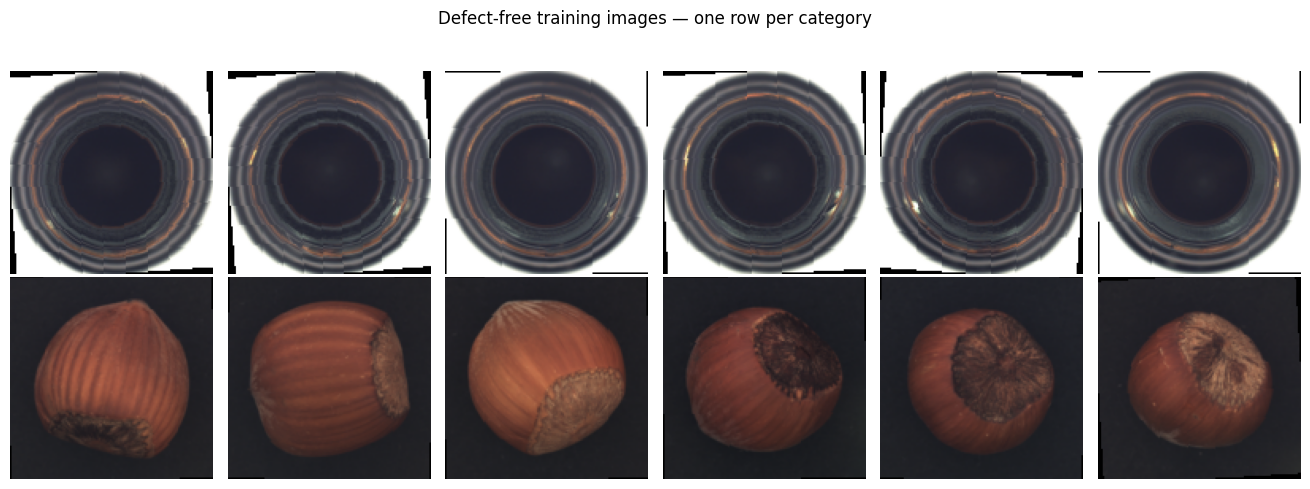

In [23]:
# Visualize a few defect-free training images from each category — quick sanity check.
CATEGORIES = ['bottle', 'hazelnut']
N_SAMPLES = 6

fig, axes = plt.subplots(len(CATEGORIES), N_SAMPLES,
                         figsize=(2.2 * N_SAMPLES, 2.4 * len(CATEGORIES)))
if len(CATEGORIES) == 1:
    axes = axes[None, :]  # keep 2D indexing when one category

for row, cat in enumerate(CATEGORIES):
    cat_dir = Path(CFG['data_root']) / cat
    if not cat_dir.exists():
        for col in range(N_SAMPLES):
            axes[row, col].text(0.5, 0.5, f'{cat}\n(not downloaded)',
                                ha='center', va='center', transform=axes[row, col].transAxes)
            axes[row, col].axis('off')
        continue

    ds = MVTecTrain(cat_dir, CFG['image_size'])
    idxs = np.random.choice(len(ds), min(N_SAMPLES, len(ds)), replace=False)
    for col, idx in enumerate(idxs):
        img = ds[idx].permute(1, 2, 0).numpy()
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(cat, rotation=0, ha='right', va='center', fontsize=11)

plt.suptitle('Defect-free training images — one row per category', y=1.02)
plt.tight_layout()
plt.show()

## 9. Forward-pass sanity check
Catches shape/OOM issues in 5 s before committing to a full run.

In [24]:
# Sanity: build mini dataloader on one category, forward 1 batch, print shapes
cat_dir_test = Path(CFG['data_root']) / 'bottle'
ds_test = CachedDataset(MVTecTrain(cat_dir_test, CFG['image_size']), has_labels=False)
loader_test = DataLoader(ds_test, batch_size=4, num_workers=0)
m_test = CompactAE(CFG['base_channels'], CFG['latent_channels'], CFG['n_down']).to(DEVICE)
x = next(iter(loader_test)).to(DEVICE)
with torch.no_grad():
    out = m_test(x)
print(f'input: {x.shape} | output: {out.shape} | params: {sum(p.numel() for p in m_test.parameters()):,}')
del m_test, ds_test, loader_test

Caching 209 train images...


  0%|          | 0/209 [00:00<?, ?it/s]

input: torch.Size([4, 3, 128, 128]) | output: torch.Size([4, 3, 128, 128]) | params: 462,307


# Zone 3 — Runs
*The actual experiments.*

## 10. Train all categories
One independent model per category. ~5 min each on T4.

In [25]:
CATEGORIES = ['bottle', 'hazelnut']

results = {}
for cat in CATEGORIES:
    model, hist, auroc, scores = train_one_category(cat, epochs=CFG['epochs'])
    results[cat] = {'auroc': auroc, 'history': hist, 'scores': scores}


  TRAINING ON: bottle
Caching 209 train images...


  0%|          | 0/209 [00:00<?, ?it/s]

Caching 83 test images...


  0%|          | 0/83 [00:00<?, ?it/s]

  epoch  40 | loss = 0.10403
  epoch  80 | loss = 0.08918
  epoch 120 | loss = 0.07142
  epoch 160 | loss = 0.06634
  epoch 200 | loss = 0.06632
  → final loss = 0.06632 | AUROC = 0.9294
  saved: /content/baseline_out/baseline_bottle.pt

  TRAINING ON: hazelnut
Caching 391 train images...


  0%|          | 0/391 [00:00<?, ?it/s]

Caching 110 test images...


  0%|          | 0/110 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  epoch  40 | loss = 0.06628
  epoch  80 | loss = 0.05979
  epoch 120 | loss = 0.05672
  epoch 160 | loss = 0.05537
  epoch 200 | loss = 0.05479
  → final loss = 0.05479 | AUROC = 0.8150
  saved: /content/baseline_out/baseline_hazelnut.pt


## 11. Backup to Drive
Copy `/content/baseline_out/` to Drive so checkpoints survive disconnect.

In [31]:
import shutil
shutil.copytree('/content/baseline_out',
                '/content/drive/MyDrive/mvtec_baselines',
                dirs_exist_ok=True)
print('Backed up to Drive ✓')

Backed up to Drive ✓


## 12. Summary table
AUROC and final loss per category, with cross-category mean.

In [27]:
print(f'\n{"Category":<15} {"AUROC":>8} {"Final Loss":>12}')
print('-'*40)
for cat, r in results.items():
    print(f'{cat:<15} {r["auroc"]:>8.4f} {r["history"][-1]:>12.5f}')
aurocs = [r['auroc'] for r in results.values()]
print('-'*40)
print(f'{"Mean":<15} {np.mean(aurocs):>8.4f}')


Category           AUROC   Final Loss
----------------------------------------
bottle            0.9294      0.06632
hazelnut          0.8150      0.05479
----------------------------------------
Mean              0.8722


## 13. Training loss curves
All categories overlaid — quick check that training converged on each.

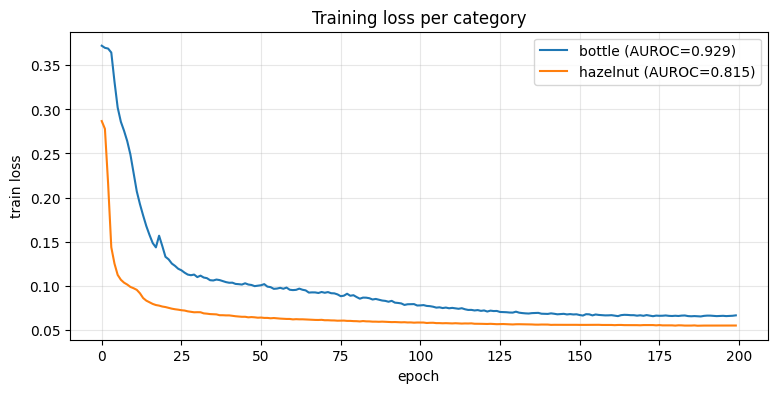

In [28]:
plt.figure(figsize=(9, 4))
for cat, r in results.items():
    plt.plot(r['history'], label=f'{cat} (AUROC={r["auroc"]:.3f})')
plt.xlabel('epoch'); plt.ylabel('train loss')
plt.legend(); plt.grid(alpha=.3); plt.title('Training loss per category'); plt.show()

## 14. Score distributions
`good` vs `defect` histograms per category. Visual confirmation of separation.

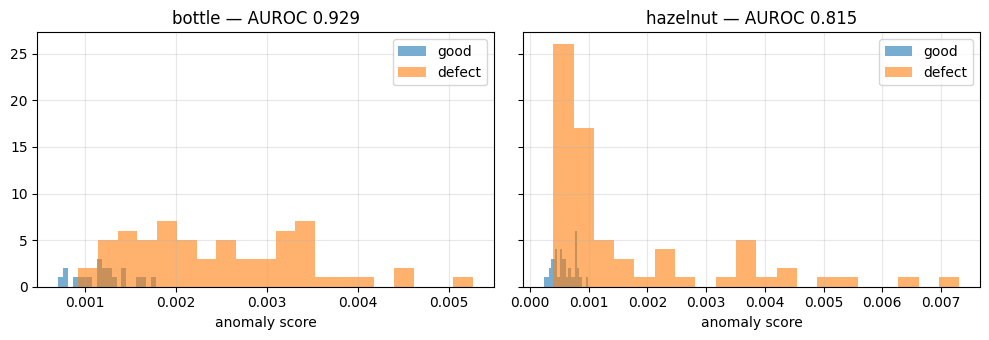

In [29]:
fig, axes = plt.subplots(1, len(results), figsize=(5*len(results), 3.5), sharey=True)
if len(results) == 1: axes = [axes]
for ax, (cat, r) in zip(axes, results.items()):
    s, l, _ = r['scores']
    ax.hist(s[l==0], bins=20, alpha=.6, label='good')
    ax.hist(s[l==1], bins=20, alpha=.6, label='defect')
    ax.set_title(f'{cat} — AUROC {r["auroc"]:.3f}')
    ax.set_xlabel('anomaly score'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 15. Qualitative reconstructions
Helper to inspect input / reconstruction / error map. Call `show_recon('bottle')` etc.

Caching 83 test images...


  0%|          | 0/83 [00:00<?, ?it/s]

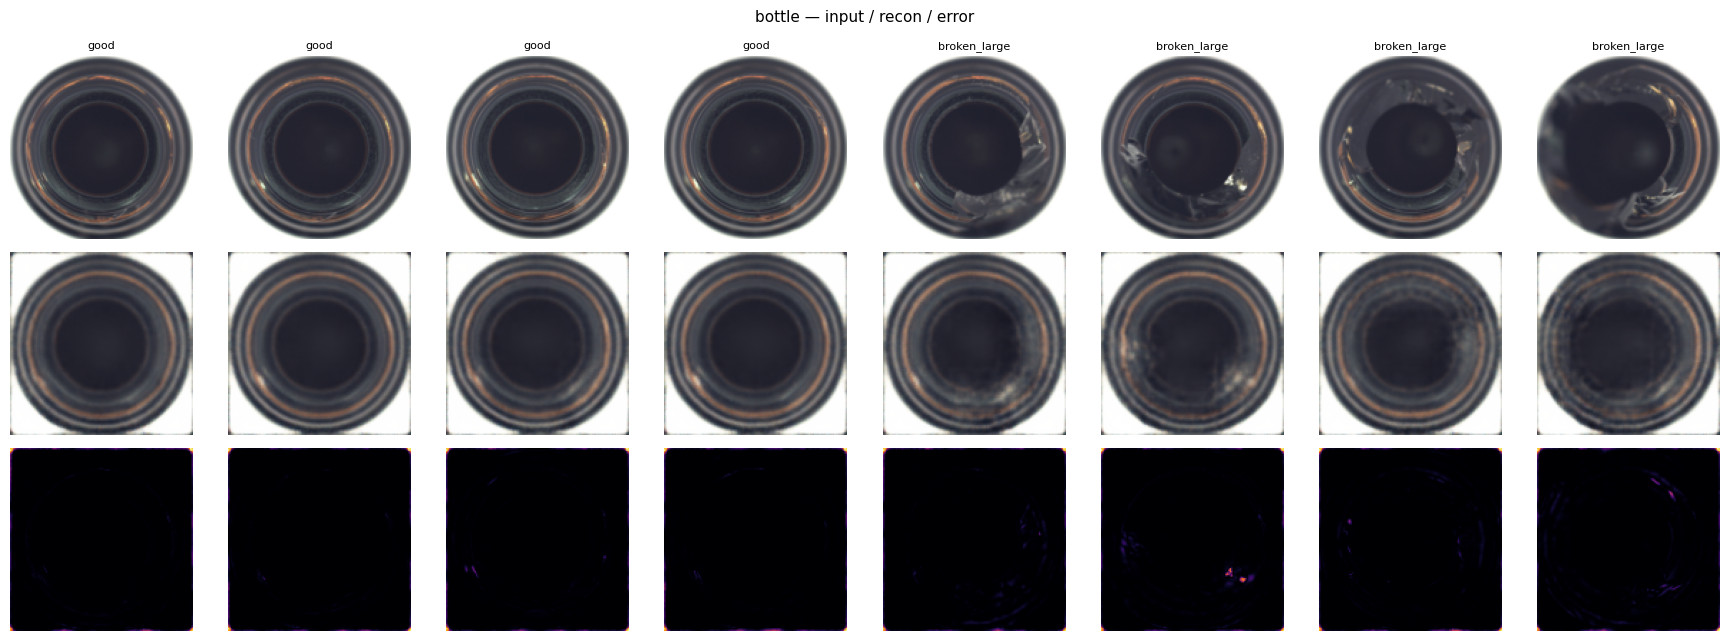

In [32]:
@torch.no_grad()
def show_recon(category, n=4):
    ckpt = torch.load(Path(CFG['out_dir']) / f'baseline_{category}.pt',
                      map_location=DEVICE, weights_only=False)
    m = CompactAE(CFG['base_channels'], CFG['latent_channels'], CFG['n_down']).to(DEVICE)
    m.load_state_dict(ckpt['state_dict']); m.eval()
    cat_dir = Path(CFG['data_root']) / category
    ds = CachedDataset(MVTecTest(cat_dir, CFG['image_size']), has_labels=True)
    fig, axes = plt.subplots(3, n*2, figsize=(2.2*n*2, 6.5))
    for col, want in enumerate([0]*n + [1]*n):
        idx = next(i for i,(_,l,_) in enumerate(ds.data) if l==want and i not in getattr(show_recon, '_seen', set()))
        show_recon._seen = getattr(show_recon, '_seen', set()) | {idx}
        x, l, d = ds[idx]; xh = m(x.unsqueeze(0).to(DEVICE)).squeeze(0).cpu()
        err = (x - xh).pow(2).mean(0)
        axes[0,col].imshow(x.permute(1,2,0)); axes[0,col].set_title(d, fontsize=8); axes[0,col].axis('off')
        axes[1,col].imshow(xh.permute(1,2,0).clamp(0,1)); axes[1,col].axis('off')
        axes[2,col].imshow(err, cmap='inferno'); axes[2,col].axis('off')
    show_recon._seen = set()
    plt.suptitle(f'{category} — input / recon / error', fontsize=11)
    plt.tight_layout(); plt.show()

# Use it:
show_recon('bottle')
# show_recon('hazelnut')

# Stage 1 — Report & Stage 2 Handoff

## 1. Objective recap

Train a compact convolutional autoencoder for unsupervised anomaly detection on MVTec AD, sized to plausibly fit the Arduino Nano 33 BLE Sense Rev 2 (256 KB SRAM, 1 MB Flash) after INT8 quantization. This baseline is what Stage 2 will compress and benchmark.

## 2. Final architecture

`CompactAE` — symmetric encoder/decoder, 3 downsamplings, no batchnorm, no skip connections.
**The architecture is identical across all categories**; only the trained weights differ.

| Property | Value |
|---|---|
| Input resolution | 128 × 128 × 3 |
| Base channels | 32 |
| Latent channels | 32 |
| Bottleneck spatial | 16 × 16 |
| Parameters | 462,307 |
| MACs / inference | 156.6 M |
| Size FP32 | 1,806 KB |
| Size INT8 (est.) | 452 KB |

The FP32 model **exceeds** the 1 MB Flash budget. INT8 quantization is required for any MCU deployment — this is the motivation for Stage 2, not a problem to fix in Stage 1.

## 3. Frozen scoring protocol

Identical for every model in every subsequent stage. Stage 2 compressed variants will be evaluated with these exact steps:

1. Per-pixel squared reconstruction error map.
2. Crop 8 pixels off each border (removes transpose-conv boundary artifacts).
3. 5 × 5 average-pool smoothing (suppresses single-pixel outliers, rewards spatially coherent errors).
4. Spatial **mean** for the image-level anomaly score.

Loss during training: 0.5 · MSE + 0.5 · (1 − SSIM). Optimizer: Adam, lr 1e-3, cosine schedule, 200 epochs.

## 4. Results

We evaluated five MVTec categories. Two reach strong baseline AUROC and proceed to Stage 2; three fall below a usable threshold and are documented as scope limitations (see Section 5).

| Category | AUROC | Final train loss | Status |
|---|---|---|---|
| `bottle` | 0.9294 | 0.06632 | ✅ Strong — proceeds to Stage 2 |
| `hazelnut` | 0.8150 | 0.05479 | ✅ Acceptable — proceeds to Stage 2 |
| `pill` | 0.7343 | 0.04447 | ⚠️ Weak — excluded |
| `carpet` | 0.4839 | 0.10901 | ❌ Fails — excluded |
| `metal_nut` | 0.4203 | 0.09166 | ❌ Fails (inverted) — excluded |

Non-deployable reference: PaDiM with a pretrained ResNet18 backbone reaches **0.994** on `bottle`. This bounds what any from-scratch compact AE could reach and frames the accuracy gap Stage 2 compression works within.

## 5. Scope and limitations — where the compact AE works

A clear pattern emerged across categories. The compact reconstruction AE achieves strong AUROC on **object categories with large structural defects** (`bottle`: broken glass; `hazelnut`: cracks) and fails on **fine-texture categories and categories with small/subtle surface defects**.

| Failure category | AUROC | Why it fails |
|---|---|---|
| `metal_nut` | 0.42 | Defects (`scratch`, `bent`, `color`) reconstruct *better* than test "good" images — the AUROC inverts. Defects are subtle surface perturbations on simple geometry that fall within the AE's reconstruction tolerance, while natural lighting/orientation variation in good images reads as more anomalous. |
| `carpet` | 0.48 | Fine high-frequency texture. The 128→16 downsampling discards exactly the detail that distinguishes good from defective carpet; good and defective both reconstruct to the same blurred average (high final loss, 0.109, confirms poor reconstruction). |
| `pill` | 0.73 | Pills reconstruct well (low loss) but defects are small and faint, so good reconstruction does not translate to good detection. Learning the right direction but weakly. |

This is a **known, documented limitation** of small reconstruction autoencoders, and is precisely why the field uses feature-distribution methods (PaDiM, PatchCore, EfficientAD) for these categories. Those methods rely on pretrained ImageNet backbones whose features are insensitive to the lighting, orientation, and texture variance that confounds raw-pixel reconstruction — but those backbones exceed our MCU budget, so they are not deployable options for this project.

We therefore **restrict the Stage 2 compression study to the two AE-viable categories** (`bottle`, `hazelnut`). Studying compression on a model already near chance (carpet, metal_nut) or in the noise floor (pill) would not yield a meaningful "accuracy cost of compression" measurement — the effect of compression would be swamped by the baseline's own weakness. The three excluded categories are retained as a deliberate negative result that bounds the applicability of the approach.

## 6. What we learned the hard way

Path to the working baseline went through several dead ends, all worth recording:

- **Too much capacity** (`base=16, latent=32`, ~150k params): model reconstructs defects as faithfully as good images. AUROC ≈ 0.68.
- **Bottleneck too tight** (`latent=8` at 8×8): model can't reconstruct anything cleanly, including good images. AUROC ≈ 0.74.
- **Boundary artifacts from transpose convs**: `max` or `top-k` pooling on the raw error map picks up boundary noise, not defects, inverting the AUROC (`max` → 0.48 on `bottle`). The 8-pixel border crop is mandatory.
- **Pure MSE**: underweights edges and textures where defects live. Mixing with SSIM matters.
- **Category selection matters and must be principled**: three of five categories failed. We select categories on the stated basis (object categories with structural defects, where reconstruction-based AD is known to work) rather than by trying categories until three pass — the latter would be data snooping.

## 7. Artifacts produced

Saved to `/content/baseline_out/` and backed up to `/content/drive/MyDrive/mvtec_baselines/`:

- `baseline_<category>.pt` — full checkpoint: state dict, config, scoring protocol, metrics, training history
- `baseline_<category>_summary.json` — flat summary for reports/plots

Checkpoints exist for all five categories; Stage 2 uses only `baseline_bottle.pt` and `baseline_hazelnut.pt`.

## 8. Stage 2 — Handoff

### What Stage 2 must do

1. Load `baseline_<cat>.pt` for each category in `['bottle', 'hazelnut']`.
2. Apply three compression families to each baseline:
   - **Post-training quantization** — INT8 (and, where feasible, mixed-precision).
   - **Structured filter pruning** — L1-norm and Taylor-importance ranking, with short fine-tuning.
   - **Knowledge distillation** — into a smaller student (fewer channels and/or fewer layers).
   - Also evaluate meaningful **combinations** (e.g., prune + INT8, distill + INT8).
3. Evaluate every variant with the **exact frozen scoring protocol from Section 3**. No per-variant tuning.
4. Produce the Pareto plot: AUROC vs. parameters, MACs, and (estimated) memory.

### Methodological commitments carried over

- Same data, same splits, same architecture base, same scoring protocol — every degree of freedom we don't lock becomes a confound that dilutes the compression comparison.
- The baseline is the reference we **degrade from**, not a SOTA target we try to reach.
- Cross-category comparison uses a single protocol — no category-specific tuning. PaDiM, PatchCore, EfficientAD all follow this convention; our results stay comparable.

### Risks Stage 2 should anticipate

- **INT8 may already be near-lossless** on this AE (small models tend to quantize well). If so, the interesting story is in pruning and distillation, with INT8 as the universal final step.
- **Structured pruning + fine-tuning** is the most code-heavy item. Plan time for it.
- **Knowledge distillation needs a sensible student architecture.** Define the student family explicitly (e.g., halve channels) before training.
- **Two categories is the deliberate scope**, not an accident. If a reviewer pushes for more, the answer is in Section 5: additional categories require a feature-based method that doesn't fit the MCU.

### Open questions for Stage 2

- Report a **single average AUROC** across the two categories, or **two separate Pareto plots**? Either is defensible; pick before producing plots.
- Where do we draw the "deployable" line for Stage 3? E.g., "any variant under 200 KB INT8 and above 0.85 AUROC moves to on-device measurement."
- For the Stage 4 adaptive policy: which compressed variants form the "quality ladder" the runtime switches between?